### import section


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

---
## 1. Load Data


In [2]:
df = pd.read_csv('data.csv')

print('Shape:', df.shape)
print()
df.head()

Shape: (569, 33)



,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,NaN
1,842517,M,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,NaN
2,84300903,M,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,NaN
3,84348301,M,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,NaN
4,84358402,M,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,NaN


---
## 2. Basic Info & Data Types


In [3]:
print('=== dtypes ===')
print(df.dtypes)
print()
print('=== info ===')
df.info()

=== dtypes ===
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
conca

---
## 3. Drop Unnamed / All-NaN Columns


In [4]:
# Drop columns that are entirely unnamed (e.g., trailing comma artefacts)
unnamed_cols = [c for c in df.columns if str(c).startswith('Unnamed')]
if unnamed_cols:
    print(f'Dropping unnamed columns: {unnamed_cols}')
    df.drop(columns=unnamed_cols, inplace=True)
else:
    print('No unnamed columns found.')

# Drop columns where ALL values are NaN
all_nan_cols = df.columns[df.isna().all()].tolist()
if all_nan_cols:
    print(f'Dropping all-NaN columns: {all_nan_cols}')
    df.drop(columns=all_nan_cols, inplace=True)
else:
    print('No all-NaN columns found.')

print(f'Shape after column cleanup: {df.shape}')

Dropping unnamed columns: ['Unnamed: 32']
No all-NaN columns found.
Shape after column cleanup: (569, 32)


---
## 4. Missing Value Analysis


In [5]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_%': missing_pct
}).query('missing_count > 0').sort_values('missing_%', ascending=False)

if missing_df.empty:
    print('No missing values found in any column.')
else:
    print(missing_df)

    # Visualise
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['missing_%'].plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Missing Values per Column (%)')
    ax.set_ylabel('%')
    ax.set_xlabel('Column')
    plt.tight_layout()
    plt.show()

No missing values found in any column.


In [6]:
# --- Handle missing values ---
# Strategy: fill numeric columns with median; fill object columns with mode

num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in num_cols:
    if df[col].isna().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Filled numeric column "{col}" NaNs with median = {median_val:.4f}')

for col in cat_cols:
    if df[col].isna().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'  Filled categorical column "{col}" NaNs with mode = "{mode_val}"')

print(f'Total missing values after imputation: {df.isna().sum().sum()}')

Total missing values after imputation: 0


---
## 5. Duplicate Row Analysis


In [7]:
n_duplicates = df.duplicated().sum()
print(f'Duplicate rows: {n_duplicates} ({n_duplicates / len(df) * 100:.2f}%)')

if n_duplicates > 0:
    print('\nSample duplicate rows:')
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns[:3])).head(10))
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'Shape after removing duplicates: {df.shape}')

Duplicate rows: 0 (0.00%)


---
## 6. Column-level Value Inspection


In [8]:
# Unique value counts per column
unique_counts = df.nunique().reset_index()
unique_counts.columns = ['column', 'unique_values']
print(unique_counts.to_string(index=False))

                 column  unique_values
                     id            569
              diagnosis              2
            radius_mean            456
           texture_mean            479
         perimeter_mean            522
              area_mean            539
        smoothness_mean            474
       compactness_mean            537
         concavity_mean            537
    concave points_mean            542
          symmetry_mean            432
 fractal_dimension_mean            499
              radius_se            540
             texture_se            519
           perimeter_se            533
                area_se            528
          smoothness_se            547
         compactness_se            541
           concavity_se            533
      concave points_se            507
            symmetry_se            498
   fractal_dimension_se            545
           radius_worst            457
          texture_worst            511
        perimeter_worst  

In [9]:
# Value counts for categorical columns
for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

--- diagnosis ---
diagnosis
B    357
M    212
Name: count, dtype: int64



---
## 7. Descriptive Statistics


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0000,30371831.4323,125020585.6122,8670.0000,869218.0000,906024.0000,8813129.0000,911320502.0000
radius_mean,569.0000,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100
texture_mean,569.0000,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800
perimeter_mean,569.0000,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000
area_mean,569.0000,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000
smoothness_mean,569.0000,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634
compactness_mean,569.0000,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454
concavity_mean,569.0000,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268
concave points_mean,569.0000,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012
symmetry_mean,569.0000,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040


---
## 8. Outlier Detection (IQR method)


In [11]:
# Exclude 'id' from outlier analysis
analysis_num_cols = [c for c in num_cols if c != 'id']

Q1 = df[analysis_num_cols].quantile(0.25)
Q3 = df[analysis_num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = ((df[analysis_num_cols] < lower_bound) | (df[analysis_num_cols] > upper_bound))
outlier_counts = outlier_mask.sum().sort_values(ascending=False)
outlier_pct = (outlier_mask.mean() * 100).round(2).sort_values(ascending=False)

outlier_summary = pd.DataFrame({
    'outlier_count': outlier_counts,
    'outlier_%': outlier_pct
}).query('outlier_count > 0')

print('Columns with outliers (IQR method):')
print(outlier_summary)
print(f'\nTotal rows with at least one outlier: {outlier_mask.any(axis=1).sum()}')

Columns with outliers (IQR method):
                         outlier_count  outlier_%
area_se                             65    11.4200
radius_se                           38     6.6800
perimeter_se                        38     6.6800
area_worst                          35     6.1500
smoothness_se                       30     5.2700
compactness_se                      28     4.9200
fractal_dimension_se                28     4.9200
symmetry_se                         27     4.7500
area_mean                           25     4.3900
fractal_dimension_worst             24     4.2200
symmetry_worst                      23     4.0400
concavity_se                        22     3.8700
texture_se                          20     3.5100
concave points_se                   19     3.3400
concavity_mean                      18     3.1600
radius_worst                        17     2.9900
compactness_worst                   16     2.8100
compactness_mean                    16     2.8100
perimeter_wors

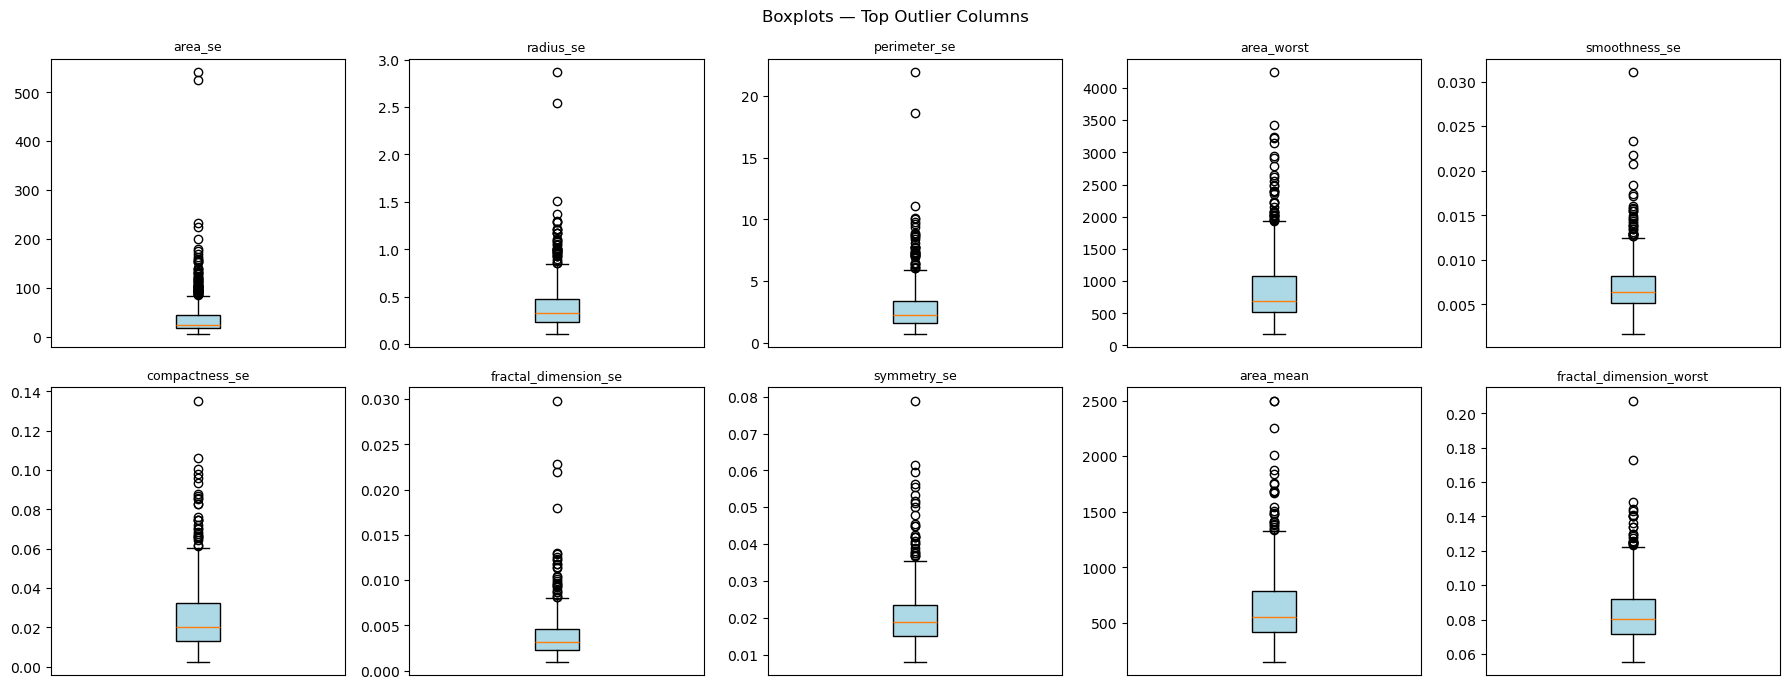

In [12]:
# Boxplots for top-10 most-outlier columns
top_outlier_cols = outlier_pct.head(10).index.tolist()

if top_outlier_cols:
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.flatten()
    for i, col in enumerate(top_outlier_cols):
        axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xticks([])
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Boxplots — Top Outlier Columns', fontsize=12)
    plt.tight_layout()
    plt.show()

---
## 9. Data Type Corrections


In [13]:
# 'id' is an identifier — keep as string to avoid accidental arithmetic
df['id'] = df['id'].astype(str)

# 'diagnosis': encode M -> 1, B -> 0 as a new column for ML readiness
if 'diagnosis' in df.columns:
    df['diagnosis'] = df['diagnosis'].str.strip().str.upper()
    df['diagnosis_encoded'] = df['diagnosis'].map({'M': 1, 'B': 0})
    unexpected = df['diagnosis'][~df['diagnosis'].isin(['M', 'B'])]
    if not unexpected.empty:
        print(f'Unexpected diagnosis values: {unexpected.unique()}')
    else:
        print('diagnosis values are clean — only M / B found.')

df.dtypes

diagnosis values are clean — only M / B found.


id                          object
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

---
## 10. Final Cleaned Dataset Summary


In [14]:
print('=== Cleaned Dataset ===' )
print(f'  Rows       : {df.shape[0]}')
print(f'  Columns    : {df.shape[1]}')
print(f'  Missing    : {df.isna().sum().sum()}')
print(f'  Duplicates : {df.duplicated().sum()}')
print()
df.head()

=== Cleaned Dataset ===
  Rows       : 569
  Columns    : 33
  Missing    : 0
  Duplicates : 0



,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_encoded
0,842302,M,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,1
1,842517,M,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,1
2,84300903,M,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,1
3,84348301,M,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,1
4,84358402,M,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,1


In [15]:
# Save cleaned data
df.to_csv('data_cleaned.csv', index=False)
print('Cleaned data saved to data_cleaned.csv')


Cleaned data saved to data_cleaned.csv


---
## EDA Visualisations


### 1. Diagnosis Distribution Analysis


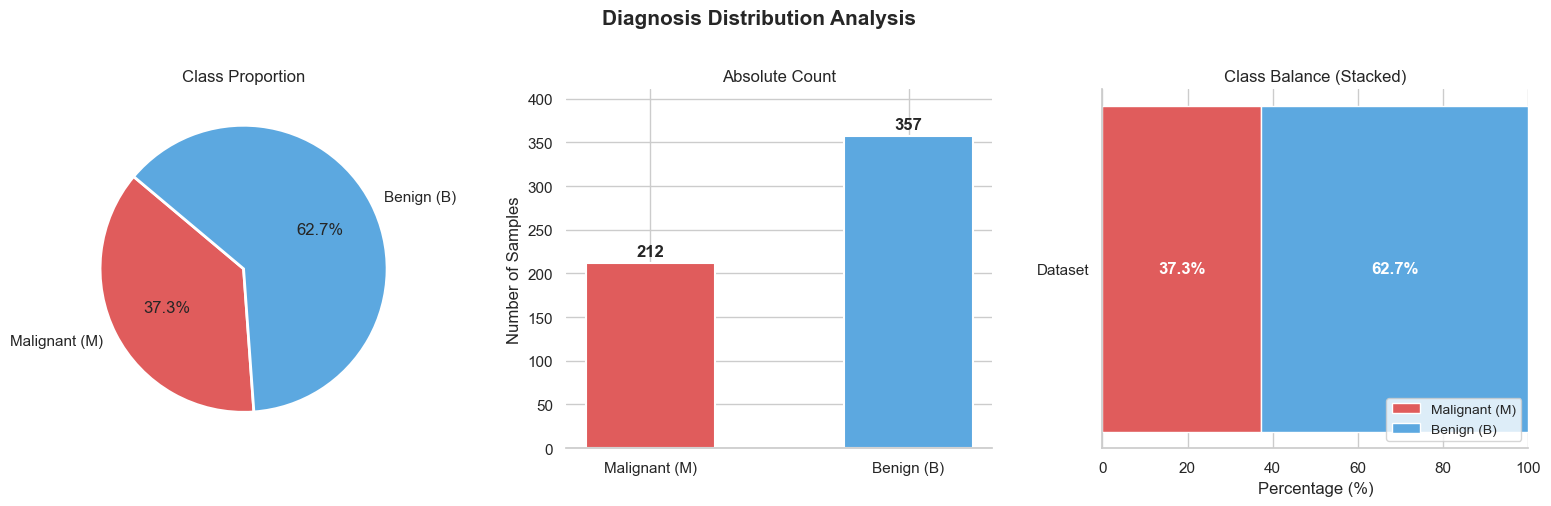

Malignant: 212 (37.3%)  |  Benign: 357 (62.7%)


In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')

diag_counts = df['diagnosis'].value_counts()
diag_labels = ['Malignant (M)', 'Benign (B)']
diag_vals   = [diag_counts.get('M', 0), diag_counts.get('B', 0)]
colors      = ['#e05c5c', '#5ca8e0']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Diagnosis Distribution Analysis', fontsize=15, fontweight='bold', y=1.01)

# --- Pie chart ---
wedges, texts, autotexts = axes[0].pie(
    diag_vals, labels=diag_labels, autopct='%1.1f%%',
    colors=colors, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
axes[0].set_title('Class Proportion', fontsize=12)

# --- Count bar chart ---
bars = axes[1].bar(diag_labels, diag_vals, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, diag_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title('Absolute Count', fontsize=12)
axes[1].set_ylabel('Number of Samples')
axes[1].set_ylim(0, max(diag_vals) * 1.15)
axes[1].tick_params(left=False)
axes[1].spines[['top','right','left']].set_visible(False)

# --- Percentage stacked bar ---
total = sum(diag_vals)
pcts  = [v / total * 100 for v in diag_vals]
axes[2].barh(['Dataset'], [pcts[0]], color=colors[0], label=diag_labels[0])
axes[2].barh(['Dataset'], [pcts[1]], left=[pcts[0]], color=colors[1], label=diag_labels[1])
axes[2].set_xlim(0, 100)
axes[2].set_xlabel('Percentage (%)')
axes[2].set_title('Class Balance (Stacked)', fontsize=12)
axes[2].legend(loc='lower right', fontsize=10)
axes[2].spines[['top','right']].set_visible(False)
for i, (pct, label) in enumerate(zip(pcts, diag_labels)):
    x_pos = pct / 2 if i == 0 else pcts[0] + pct / 2
    axes[2].text(x_pos, 0, f'{pct:.1f}%', ha='center', va='center',
                 color='white', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_01_diagnosis_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Malignant: {diag_vals[0]} ({pcts[0]:.1f}%)  |  Benign: {diag_vals[1]} ({pcts[1]:.1f}%)')


### 2. Tumor Size Characteristics Analysis


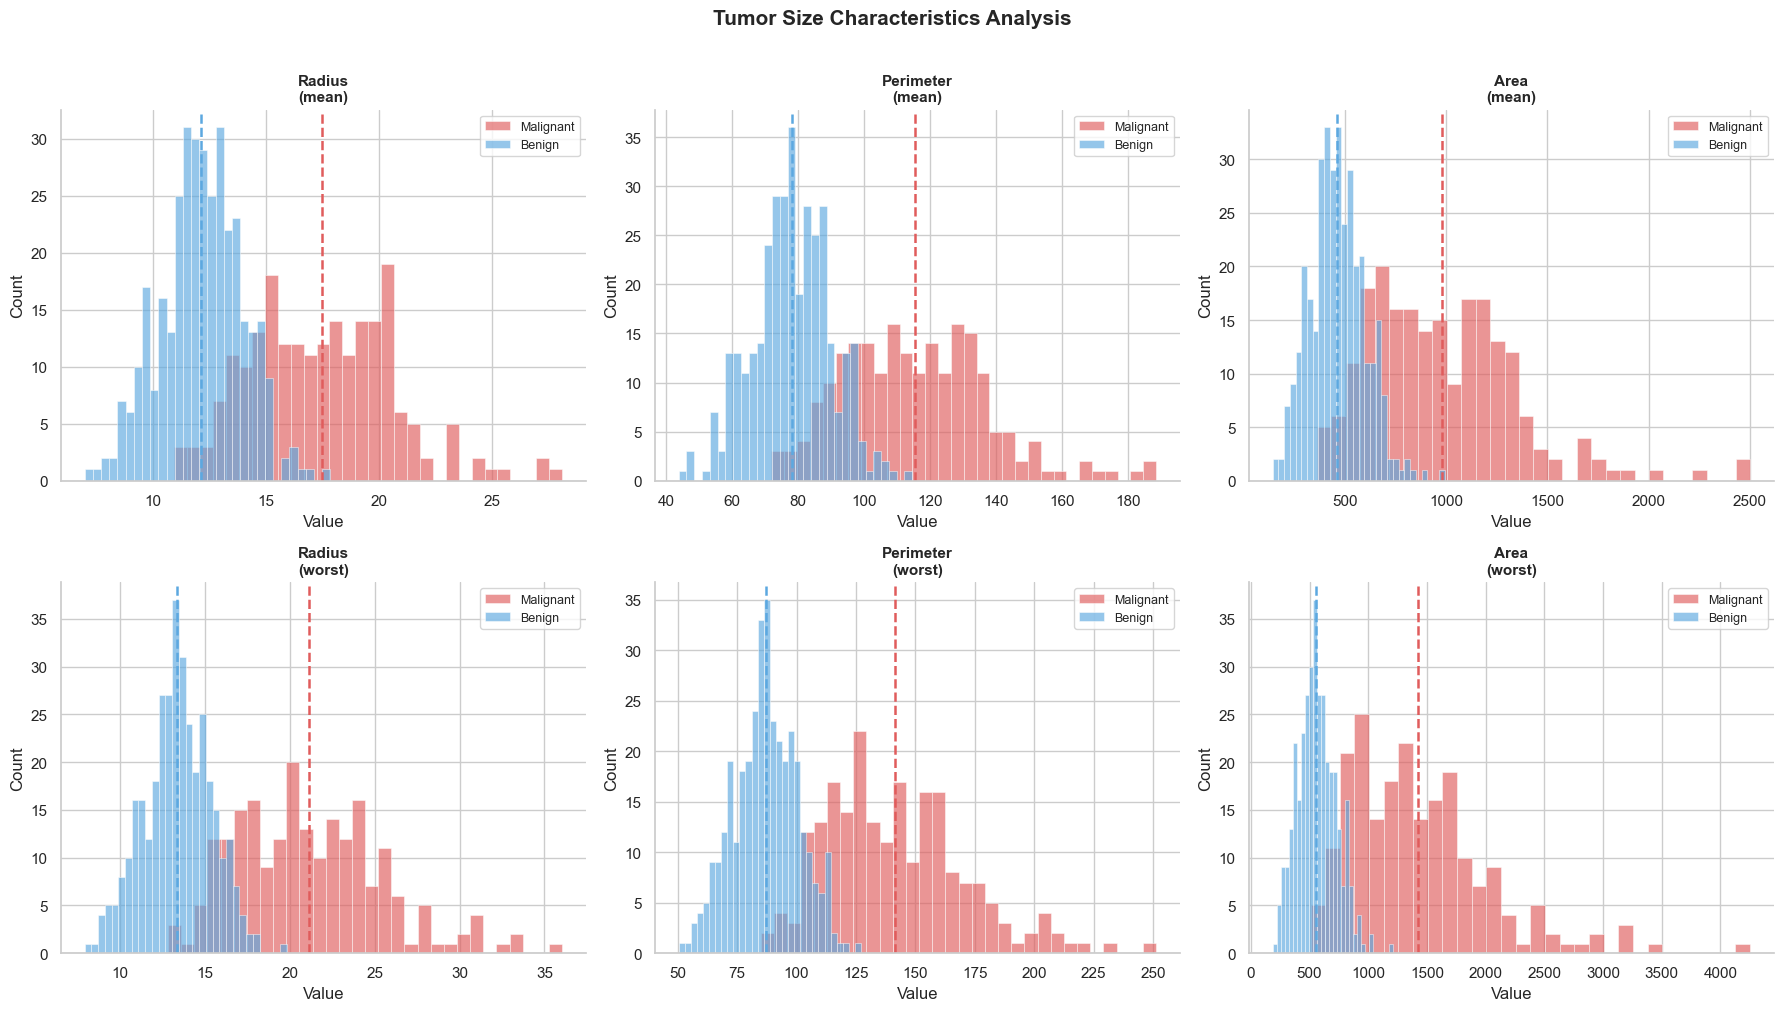

In [17]:
size_features = ['radius_mean', 'perimeter_mean', 'area_mean',
                 'radius_worst', 'perimeter_worst', 'area_worst']
labels_map = {
    'radius_mean': 'Radius\n(mean)', 'perimeter_mean': 'Perimeter\n(mean)', 'area_mean': 'Area\n(mean)',
    'radius_worst': 'Radius\n(worst)', 'perimeter_worst': 'Perimeter\n(worst)', 'area_worst': 'Area\n(worst)'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Tumor Size Characteristics Analysis', fontsize=15, fontweight='bold', y=1.01)
palette = {'M': '#e05c5c', 'B': '#5ca8e0'}

for ax, feat in zip(axes.flat, size_features):
    for diag, color in palette.items():
        vals = df.loc[df['diagnosis'] == diag, feat].dropna()
        ax.hist(vals, bins=30, alpha=0.65, color=color,
                label='Malignant' if diag == 'M' else 'Benign',
                edgecolor='white', linewidth=0.5)
        ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.8)
    ax.set_title(labels_map[feat], fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot_02_tumor_size.png', dpi=150, bbox_inches='tight')
plt.show()


### 3. Tumor Shape Irregularity Analysis


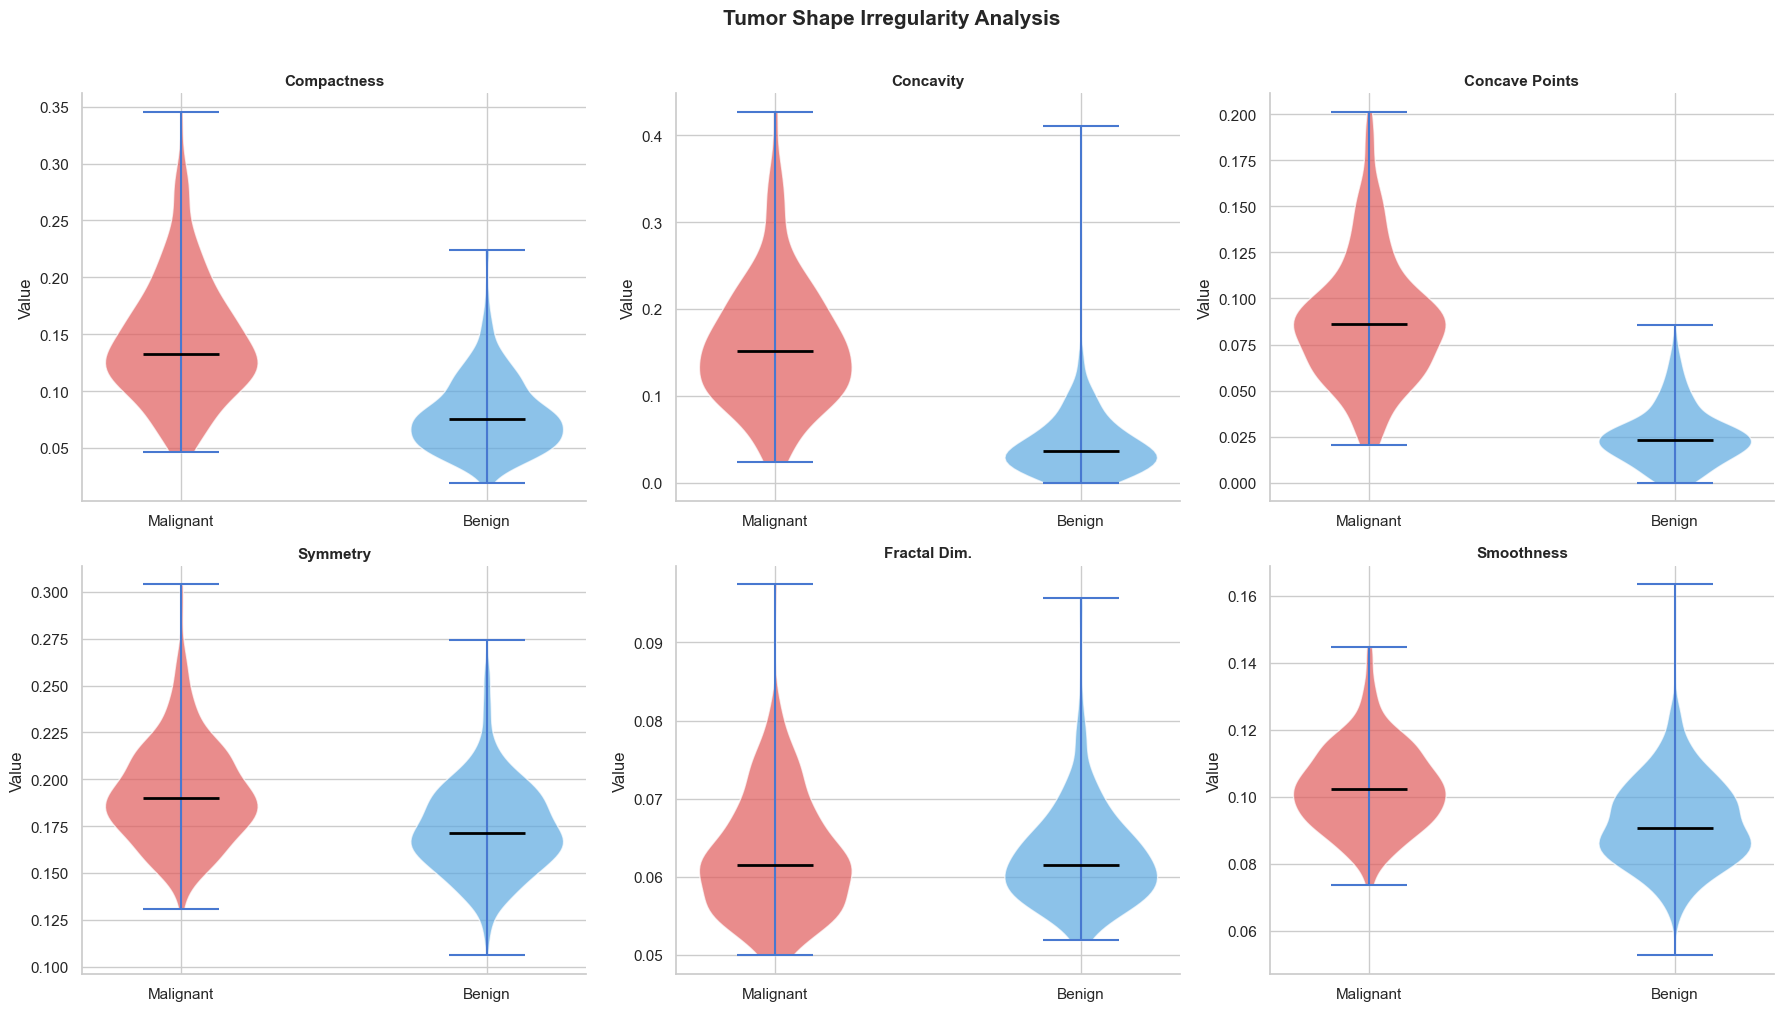

In [18]:
shape_features = ['compactness_mean', 'concavity_mean', 'concave points_mean',
                  'symmetry_mean', 'fractal_dimension_mean', 'smoothness_mean']
shape_labels   = ['Compactness', 'Concavity', 'Concave Points',
                  'Symmetry', 'Fractal Dim.', 'Smoothness']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Tumor Shape Irregularity Analysis', fontsize=15, fontweight='bold', y=1.01)
palette = {'M': '#e05c5c', 'B': '#5ca8e0'}

for ax, feat, lbl in zip(axes.flat, shape_features, shape_labels):
    data_plot = [df.loc[df['diagnosis'] == d, feat].dropna().values for d in ['M', 'B']]
    vp = ax.violinplot(data_plot, positions=[1, 2], showmedians=True, showextrema=True)
    for i, (body, color) in enumerate(zip(vp['bodies'], ['#e05c5c', '#5ca8e0'])):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    vp['cmedians'].set_color('black')
    vp['cmedians'].set_linewidth(2)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Malignant', 'Benign'])
    ax.set_title(lbl, fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot_03_tumor_shape.png', dpi=150, bbox_inches='tight')
plt.show()


### 4. Correlation and Feature Dependency Analysis


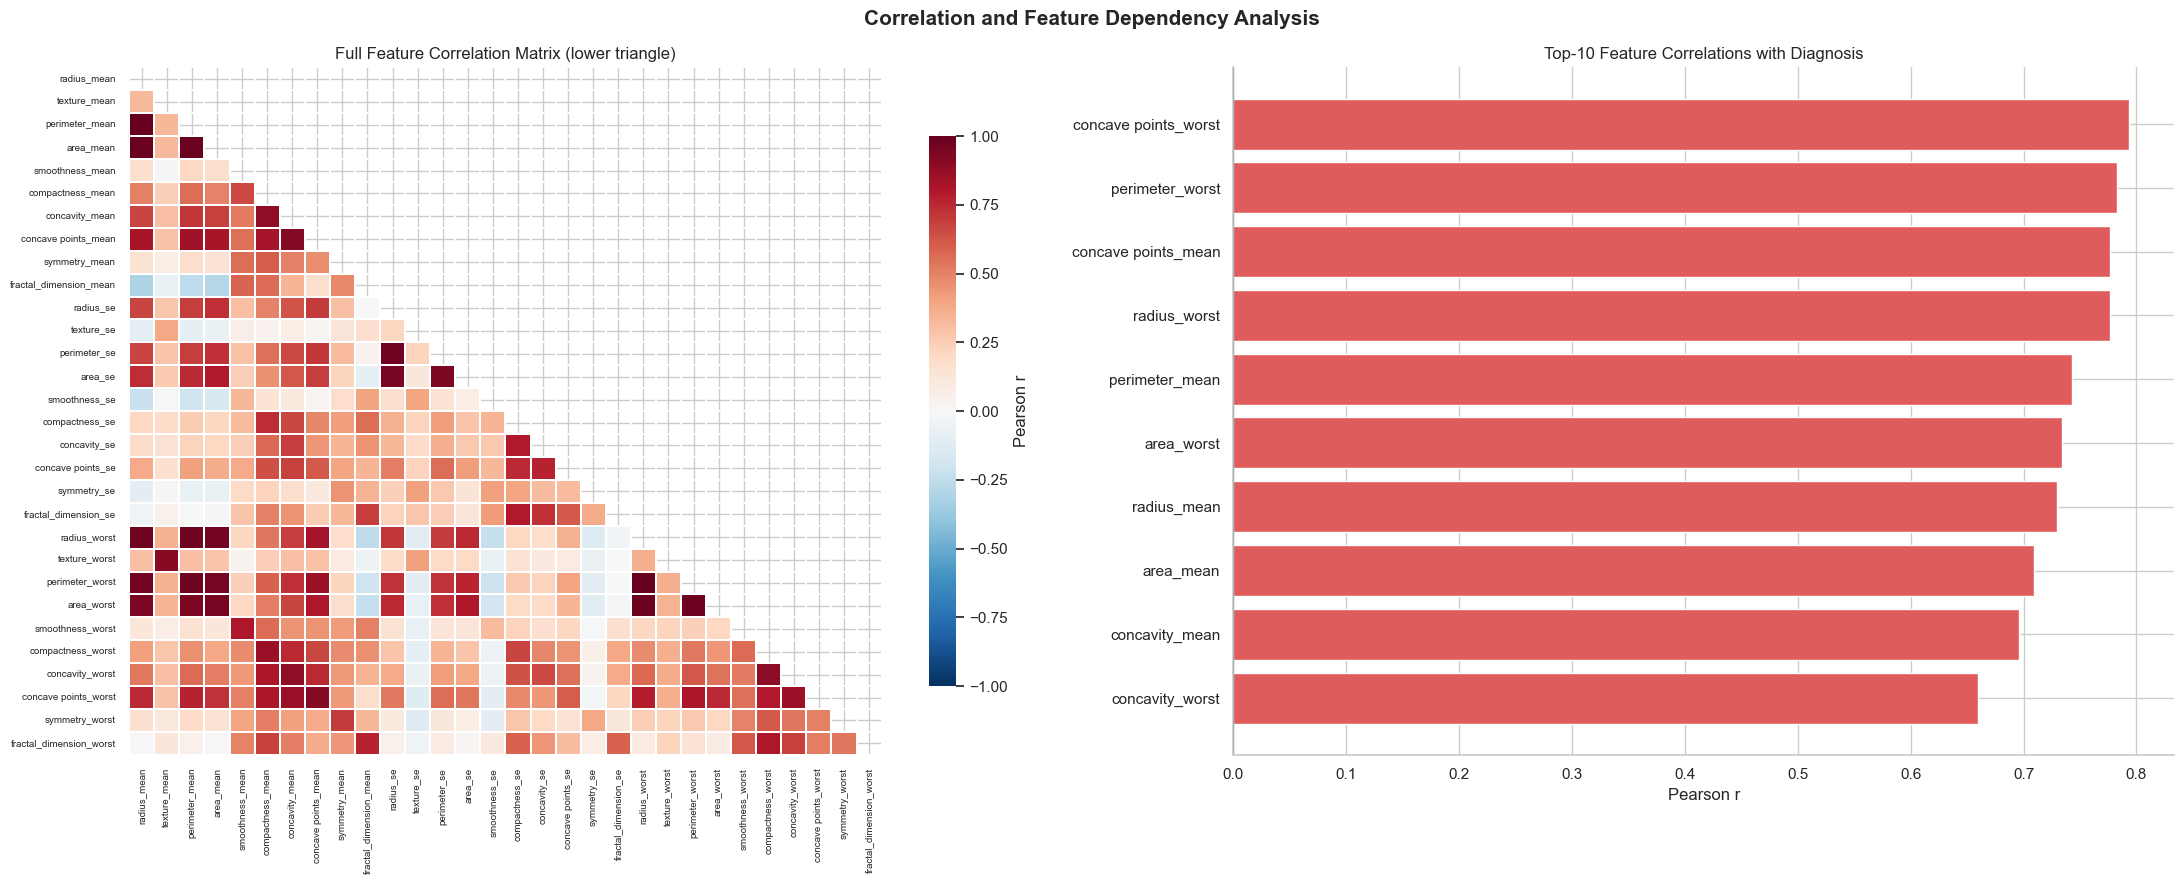

In [19]:
numeric_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c not in ['id', 'diagnosis_encoded', 'Unnamed: 32']]

# Full correlation heatmap
corr = df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Correlation and Feature Dependency Analysis', fontsize=15, fontweight='bold')

# --- Full heatmap ---
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[0], cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, annot=False,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
axes[0].set_title('Full Feature Correlation Matrix (lower triangle)', fontsize=12)
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

# --- Top-10 correlation with diagnosis_encoded ---
if 'diagnosis_encoded' in df.columns:
    corr_diag = df[numeric_cols + ['diagnosis_encoded']].corr()['diagnosis_encoded'].drop('diagnosis_encoded')
    top10 = corr_diag.abs().sort_values(ascending=False).head(10)
    top10_vals = corr_diag[top10.index]
    bar_colors = ['#e05c5c' if v > 0 else '#5ca8e0' for v in top10_vals]
    axes[1].barh(top10.index[::-1], top10_vals.values[::-1], color=bar_colors[::-1], edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title('Top-10 Feature Correlations with Diagnosis', fontsize=12)
    axes[1].set_xlabel('Pearson r')
    axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot_04_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


### 5. Predictive Feature Importance Analysis


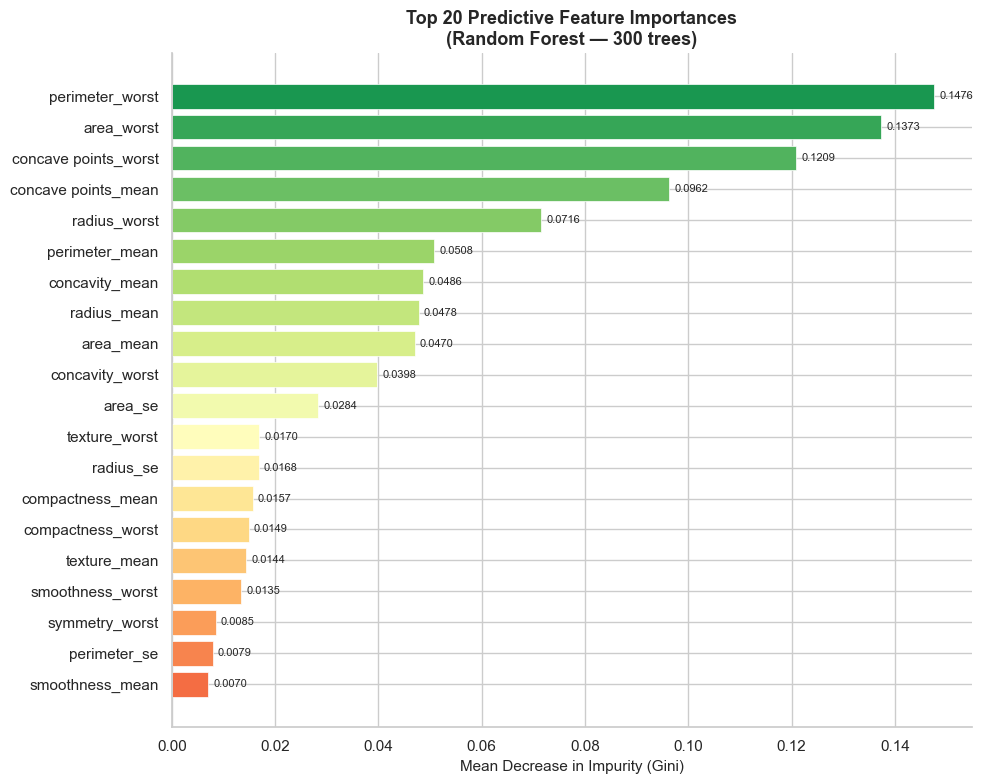

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

feat_cols = [c for c in df.select_dtypes(include=np.number).columns
             if c not in ['id', 'diagnosis_encoded', 'Unnamed: 32']]
X = df[feat_cols].dropna(axis=1)
y = df['diagnosis_encoded'] if 'diagnosis_encoded' in df.columns else LabelEncoder().fit_transform(df['diagnosis'])

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
top20 = importances.tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top20)))
bars = ax.barh(top20.index, top20.values, color=colors_imp, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Mean Decrease in Impurity (Gini)', fontsize=11)
ax.set_title('Top 20 Predictive Feature Importances\n(Random Forest — 300 trees)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('plot_05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### 6. Principal Component Analysis (PCA)


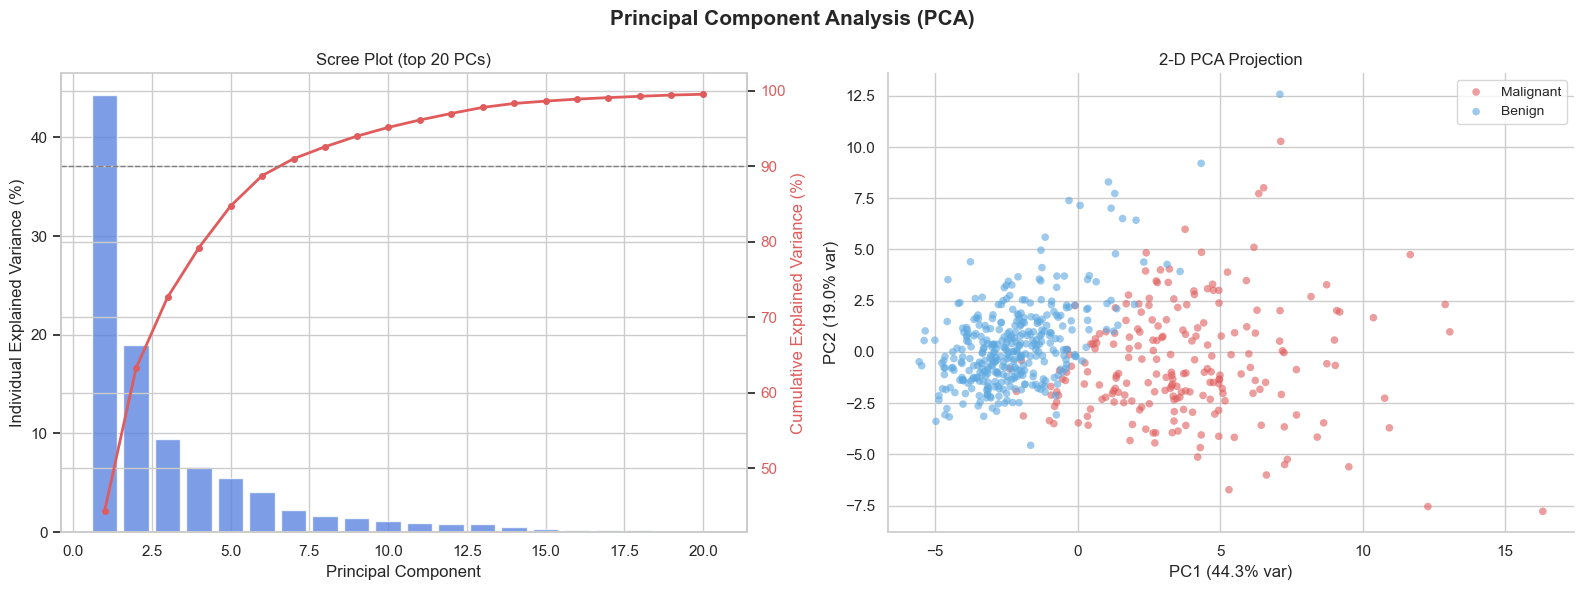

PC1+PC2 explain 63.2% of total variance


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feat_cols = [c for c in df.select_dtypes(include=np.number).columns
             if c not in ['id', 'diagnosis_encoded', 'Unnamed: 32']]
X_pca = df[feat_cols].dropna(axis=1).values
y_pca = df['diagnosis'].values

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca_full = PCA()
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Principal Component Analysis (PCA)', fontsize=15, fontweight='bold')

# --- Scree + cumulative variance ---
n_show = min(20, len(explained))
axes[0].bar(range(1, n_show + 1), explained[:n_show] * 100,
            color='#5c85e0', alpha=0.8, label='Individual')
ax_twin = axes[0].twinx()
ax_twin.plot(range(1, n_show + 1), cumulative[:n_show] * 100,
             color='#e05c5c', marker='o', markersize=4, linewidth=2, label='Cumulative')
ax_twin.axhline(90, color='grey', linestyle='--', linewidth=1)
ax_twin.set_ylabel('Cumulative Explained Variance (%)', color='#e05c5c')
ax_twin.tick_params(axis='y', labelcolor='#e05c5c')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Individual Explained Variance (%)')
axes[0].set_title('Scree Plot (top 20 PCs)', fontsize=12)
axes[0].spines[['top']].set_visible(False)

# --- 2-D PCA scatter ---
palette = {'M': '#e05c5c', 'B': '#5ca8e0'}
for diag, color in palette.items():
    mask = y_pca == diag
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, alpha=0.6,
                    s=30, label='Malignant' if diag == 'M' else 'Benign', edgecolors='none')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')
axes[1].set_title('2-D PCA Projection', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot_06_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'PC1+PC2 explain {(explained[0]+explained[1])*100:.1f}% of total variance')


### 7. Malignancy Pattern Discovery


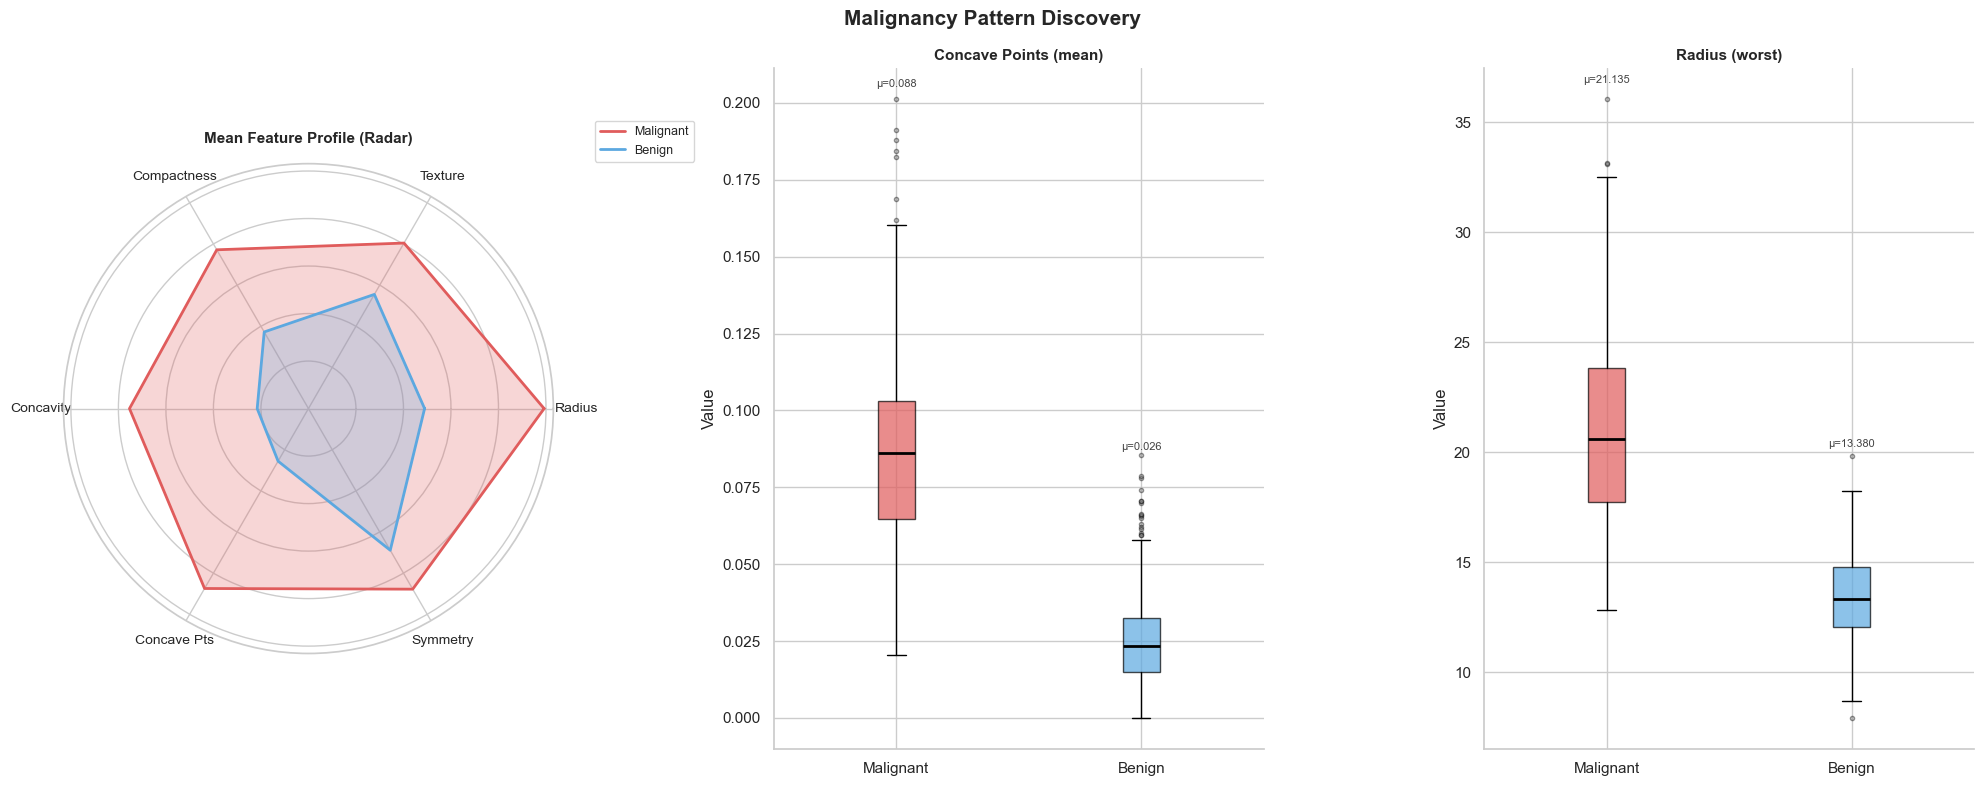

In [22]:
# Radar chart + pair plot for top features
from matplotlib.patches import FancyArrowPatch
from math import pi

top_radar_feats = ['radius_mean', 'texture_mean', 'compactness_mean',
                   'concavity_mean', 'concave points_mean', 'symmetry_mean']
radar_labels = ['Radius', 'Texture', 'Compactness', 'Concavity', 'Concave Pts', 'Symmetry']

# Normalise to 0-1 per feature for radar
def norm(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

M_vals = [norm(df[f])[df['diagnosis'] == 'M'].mean() for f in top_radar_feats]
B_vals = [norm(df[f])[df['diagnosis'] == 'B'].mean() for f in top_radar_feats]

N = len(top_radar_feats)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
M_vals += M_vals[:1]
B_vals += B_vals[:1]

fig = plt.figure(figsize=(20, 8))
fig.suptitle('Malignancy Pattern Discovery', fontsize=15, fontweight='bold')

# --- Radar ---
ax_r = fig.add_subplot(131, polar=True)
ax_r.plot(angles, M_vals, color='#e05c5c', linewidth=2, linestyle='solid', label='Malignant')
ax_r.fill(angles, M_vals, color='#e05c5c', alpha=0.25)
ax_r.plot(angles, B_vals, color='#5ca8e0', linewidth=2, linestyle='solid', label='Benign')
ax_r.fill(angles, B_vals, color='#5ca8e0', alpha=0.25)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(radar_labels, fontsize=10)
ax_r.set_title('Mean Feature Profile (Radar)', fontsize=11, fontweight='bold', pad=15)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax_r.set_yticklabels([])

# --- Box plots: concave points_mean & radius_worst ---
for idx, (feat, lbl) in enumerate(
        [('concave points_mean', 'Concave Points (mean)'),
         ('radius_worst', 'Radius (worst)')]):
    ax_b = fig.add_subplot(1, 3, idx + 2)
    data_M = df.loc[df['diagnosis'] == 'M', feat].dropna()
    data_B = df.loc[df['diagnosis'] == 'B', feat].dropna()
    bp = ax_b.boxplot([data_M, data_B], patch_artist=True,
                      medianprops=dict(color='black', linewidth=2),
                      flierprops=dict(marker='o', markerfacecolor='grey',
                                      markersize=3, alpha=0.4))
    for patch, color in zip(bp['boxes'], ['#e05c5c', '#5ca8e0']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax_b.set_xticklabels(['Malignant', 'Benign'])
    ax_b.set_title(lbl, fontsize=11, fontweight='bold')
    ax_b.set_ylabel('Value')
    ax_b.spines[['top', 'right']].set_visible(False)
    # Annotate means
    for x, data in [(1, data_M), (2, data_B)]:
        ax_b.text(x, data.max() * 1.02, f'μ={data.mean():.3f}',
                  ha='center', fontsize=8, color='#444')

plt.tight_layout()
plt.savefig('plot_07_malignancy_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
